In [1]:
#dependencias
import geopandas as gpd
import matplotlib.pyplot as plt
import re
import pandas as pd
import sys
from pathlib import Path

Stored 'ruta' (str)
Sistema de Coordenadas (CRS): EPSG:4326
Cantidad de tramos: 46283

Primeras filas de datos (Atributos):


,osm_id,name,highway,waterway,aerialway,barrier,man_made,z_order,other_tags,geometry
0,7981159,Irene Morales,secondary,None,None,None,None,6.0,"""lanes""=>""3"",""lit""=>""yes"",""maxspeed""=>""50"",""ma...","LINESTRING (-70.63704 -33.43686, -70.63685 -33..."
1,7981313,Teatinos,secondary,None,None,None,None,6.0,"""cycleway:right""=>""track"",""lanes""=>""2"",""oneway...","LINESTRING (-70.65552 -33.43238, -70.65558 -33..."
2,7981317,San Antonio,primary,None,None,None,None,7.0,"""lanes""=>""4"",""oneway""=>""yes"",""surface""=>""aspha...","LINESTRING (-70.64872 -33.43309, -70.64874 -33..."
3,7981319,Miraflores,tertiary,None,None,None,None,4.0,"""lanes""=>""2"",""lit""=>""yes"",""maxspeed""=>""50"",""on...","LINESTRING (-70.64491 -33.44238, -70.64494 -33..."
4,7991807,Ismael Valdes Vergara,secondary,None,None,None,None,6.0,"""bus:lanes""=>""yes|yes|designated|designated"",""...","LINESTRING (-70.65212 -33.43308, -70.65208 -33..."


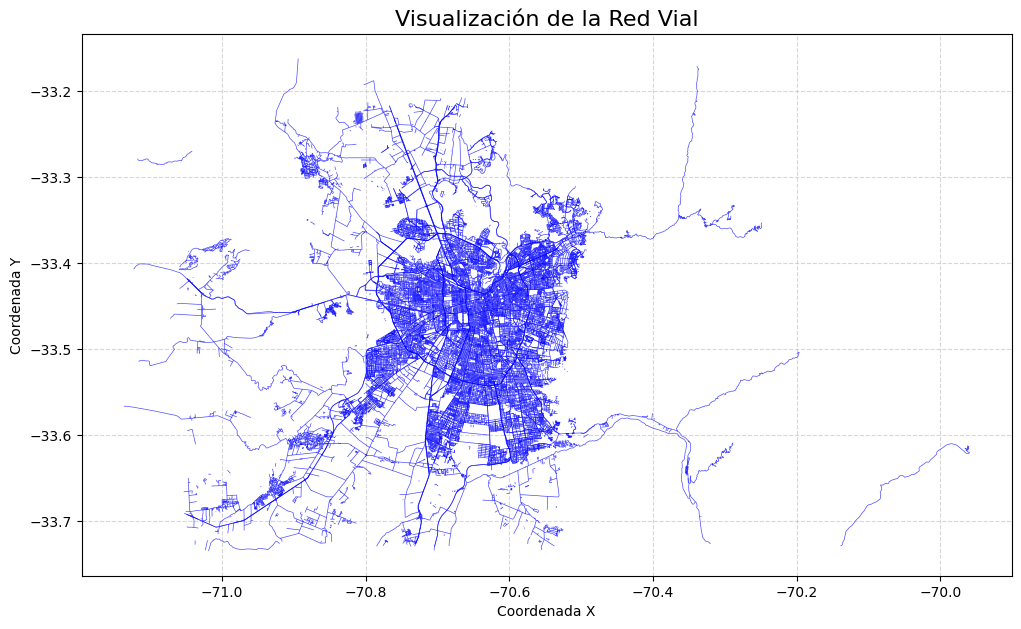

In [13]:
#Configuración de la ruta del archivo
# .shp, .dbf, .shx y .prj en la misma carpeta

#ubuntu
#ruta = '/home/ubuntu/projects/analisis_espacial_marginalNoise/'

#windows
ruta = 'E:/PROYECTOS/analisis_espacial_marginalNoise/'
%store ruta

Path(ruta) / 'data' / 'RedVial' / 'RedVial.shp'

archivo_shapefile = Path(ruta) / 'data' / 'RedVial' / 'RedVial.shp'

try:
    #Cargar la red vial
    red_vial = gpd.read_file(archivo_shapefile)
    
    print(f"Sistema de Coordenadas (CRS): {red_vial.crs}")
    print(f"Cantidad de tramos: {len(red_vial)}")
    print("\nPrimeras filas de datos (Atributos):")
    display(red_vial.head())

    #Visualización geometrica básica
    fig, ax = plt.subplots(figsize=(12, 12))
    red_vial.plot(ax=ax, color='blue', linewidth=0.5, alpha=0.7)
    ax.set_title("Visualización de la Red Vial", fontsize=16)
    ax.set_xlabel("Coordenada X")
    ax.set_ylabel("Coordenada Y")
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.show()

except Exception as e:
    print(f"Error al leer el archivo: {e}")
    print("Verifica que la ruta sea correcta y que tengas instaladas las dependencias.")

Extrayendo velocidad y carriles de 'other_tags'...

Mapa de Velocidades Máximas (Input para Greenshields)


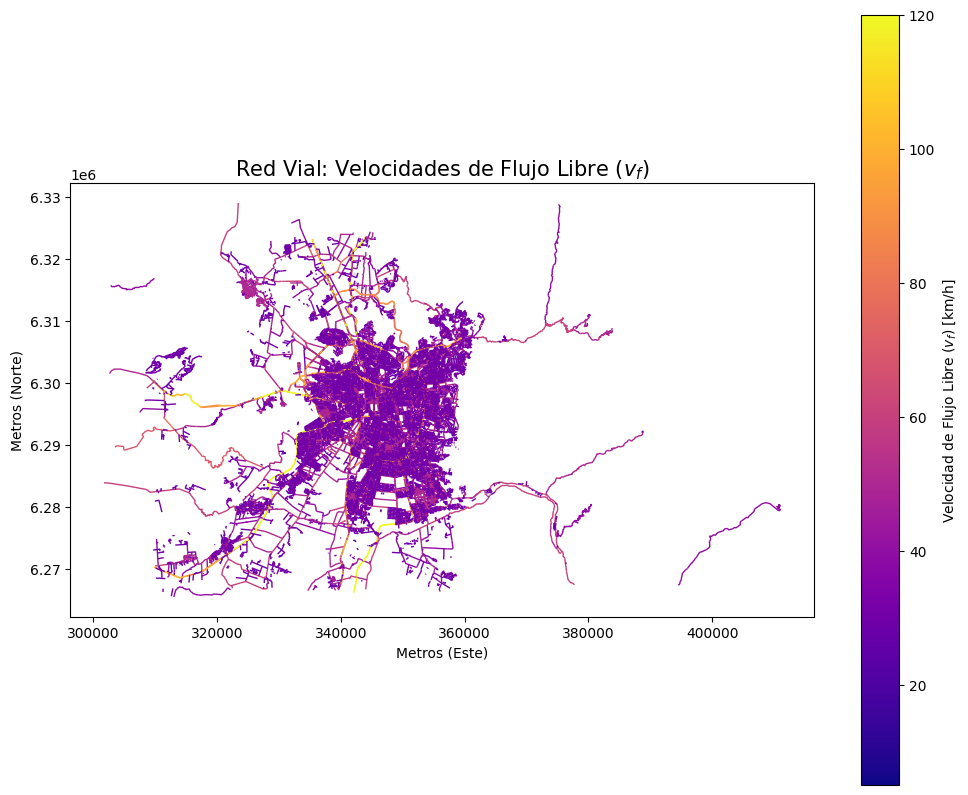


Primeras filas con datos extraídos:


,name,highway,maxspeed,lanes,velocidad_vf
0,Irene Morales,secondary,50,3,50
1,Teatinos,secondary,NaN,2,50
2,San Antonio,primary,NaN,4,60
3,Miraflores,tertiary,50,2,50
4,Ismael Valdes Vergara,secondary,NaN,4,50


Stored 'red_vial' (GeoDataFrame)


In [24]:
#Función para extraer datos de la columna 'other_tags'
# Transforma el string '"key"=>"value"' en un diccionario de Python
def parse_osm_tags(tag_str):
    if not isinstance(tag_str, str):
        return {}
    # Expresión regular para capturar texto entre comillas separado por =>
    pattern = r'"([^"]+)"=>"([^"]+)"'
    matches = re.findall(pattern, tag_str)
    return dict(matches)

#Limpieza de Velocidad (maxspeed) -> Será nuestra Vf (Velocidad flujo libre)
# Si no hay dato, asumimos valores por defecto según el tipo de vía (highway)
def estimar_velocidad(row):
    if pd.notna(row.get('maxspeed')):
        # Limpiar texto (ej: convertir "50 km/h" a 50)
        speed = re.findall(r'\d+', str(row['maxspeed']))
        return int(speed[0]) if speed else 40
    
    # Valores por defectos según tipo de vía
    tipo = row['highway']
    if tipo == 'motorway': return 100
    elif tipo == 'primary': return 60
    elif tipo == 'secondary': return 50
    elif tipo == 'tertiary': return 40
    else: return 30 # residential, service, etc.

#PROCESAMIENTO

# A. Convertir 'other_tags' en columnas reales y concatenar con el .dgbf
print("Extrayendo velocidad y carriles de 'other_tags'...")
tags_parsed = red_vial['other_tags'].apply(parse_osm_tags)
df_tags = pd.DataFrame(tags_parsed.tolist())
red_vial = pd.concat([red_vial, df_tags], axis=1)

red_vial = red_vial.loc[:, ~red_vial.columns.duplicated()].copy()
red_vial['velocidad_vf'] = red_vial.apply(estimar_velocidad, axis=1)

#Reproyección a Metros (CRÍTICO para cálculo de ruido)
# Detectamos si está en lat/lon y convertimos a UTM 19S (EPSG:32719 para Stgo/Viña)
if red_vial.crs.is_geographic:
    print("Reproyectando mapa a UTM Zona 19S (Metros)...")
    red_vial = red_vial.to_crs(epsg=32719)


#VISUALIZACIÓN
print("\nMapa de Velocidades Máximas (Input para Greenshields)")
fig, ax = plt.subplots(figsize=(12, 10))

# Graficamos coloreando por la velocidad extraída
red_vial.plot(column='velocidad_vf', 
            ax=ax, 
            legend=True,
            cmap='plasma', # Colores cálidos
            legend_kwds={'label': "Velocidad de Flujo Libre ($v_f$) [km/h]"},
            linewidth=1)

ax.set_title("Red Vial: Velocidades de Flujo Libre ($v_f$)", fontsize=15)
ax.set_xlabel("Metros (Este)")
ax.set_ylabel("Metros (Norte)")
plt.show()

# Verificación de datos extraídos
print("\nPrimeras filas con datos extraídos:")
cols_interes = ['name', 'highway', 'maxspeed', 'lanes', 'velocidad_vf']
# Filtramos solo columnas que existen para evitar errores si 'lanes' venía vacío
cols_mostrar = [c for c in cols_interes if c in red_vial.columns]
display(red_vial[cols_mostrar].head())

%store red_vial

In [25]:
# mapa interactivo para mayor resolucion
paleta = 'plasma_r'  # Puedes cambiar a 'viridis', 'magma', 'coolwarm', etc.

mapa_interactivo = red_vial.explore(
    column='velocidad_vf', # Columna para colorear
    cmap=paleta,
    tiles='CartoDB positron',   # Fondo del mapa (limpio y gris para resaltar datos)
    style_kwds={
        'weight': 3, # Grosor de la línea
        'opacity': 0.8 # Transparencia
    },
    tooltip=['name', 'highway', 'maxspeed', 'lanes', 'velocidad_vf'], # Datos al pasar el mouse
    popup=True, # Al hacer clic muestra todos los datos
    legend=True # Mostrar leyenda de colores
)

mapa_interactivo.save(Path( ruta ) / 'data' / 'data_generada' / 'mapa_velocidades.html')
print("\nMapa velocidades guardado")

#guardar red vial procesada
red_vial.to_file(Path(ruta) / 'data' / 'data_generada' / 'red_vial_procesada.gpkg', driver="GPKG")
print("Archivo 'red_vial_procesada.gpkg' guardado")


Mapa velocidades guardado
Archivo 'red_vial_procesada.gpkg' guardado
